In [1]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/adaptive_al /home/dhuseljic/mlflow/

receiving incremental file list
adaptive_al/al.db

sent 8,810 bytes  received 123,916 bytes  265,452.00 bytes/sec
total size is 2,478,080  speedup is 18.67


In [2]:
import os
import mlflow
import numpy as np
import pylab as plt
import matplotlib.pyplot as plt
import matplotlib as mpl

from collections import defaultdict
from pathlib import Path
from cycler import cycler

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (3, 2),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,
    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    # Save figure settings
    "savefig.dpi": 300,
}
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#9C7AA1", "#DAB66C", "#A2D5C6", "#E699B3"])

plot_dir = Path('/home/dhuseljic/paper_plots/adaptive_al/')
os.makedirs(plot_dir, exist_ok=True)

# uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/perf_dal_2.db'
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/al.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

print([exp.name for exp in client.search_experiments()])

['general_v2', 'baselines', 'general_v1', 'Default']


In [3]:
def get_runs(uri, exp_name, query_list=""):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
    if len(runs) == 0:
        print(f'No runs found with query list {query_list}.')
    runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
    return runs

def get_avg_lc(runs, metric='accuracy'):
    lcs = []
    for run in runs:
        lcs.append([m.value for m in client.get_metric_history(run.info.run_id, metric)])
    avg_lc = np.mean(lcs, axis=0)
    return avg_lc

In [4]:
runs_random = get_runs(uri, "baselines", ["parameter.dataset.name = 'cifar10'", "parameter.al.strategy = 'random'"])

tmp_run = runs_random[0]
acq_size = eval(tmp_run.data.params['al.acq_size'])
num_acq = eval(tmp_run.data.params['al.num_acq'])
budget = acq_size + num_acq*acq_size
axis = np.arange(acq_size, budget+1, acq_size)

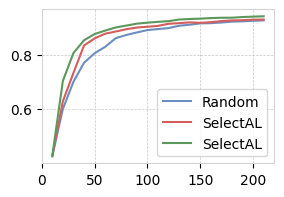

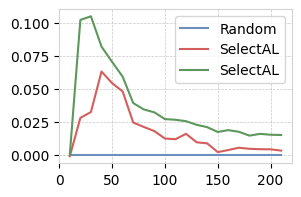

In [ ]:
runs_selectal = get_runs(uri, "general_v1", ["parameter.dataset.name = 'cifar10'", "parameter.al.strategy = 'select_al'"])
runs_selectal2 = get_runs(uri, "general_v2", ["parameter.dataset.name = 'cifar10'", "parameter.al.strategy = 'select_al'"])
runs_tcm = get_runs(uri, "baselines", ["parameter.dataset.name = 'cifar10'", "parameter.al.strategy = 'tcm'"])

avg_lc_random = get_avg_lc(runs_random)
avg_lc_selectal = get_avg_lc(runs_selectal)
avg_lc_tcm = get_avg_lc(runs_tcm)

plt.figure()
plt.plot(axis, avg_lc_random, label='Random')
plt.plot(axis, avg_lc_selectal, label='SelectAL')
plt.plot(axis, avg_lc_tcm, label='SelectAL')
plt.legend()

plt.figure()
plt.plot(axis, avg_lc_random - avg_lc_random, label='Random')
plt.plot(axis, avg_lc_selectal - avg_lc_random, label='SelectAL')
plt.plot(axis, avg_lc_tcm - avg_lc_random, label='SelectAL')
plt.legend()

plt.show()